In [40]:
from fredapi import Fred
from dotenv import load_dotenv
import os
import pandas as pd
import yfinance as yf

project_root = '/Users/namansoni/Project/macro-regime-classifier'

load_dotenv()
FRED_API_KEY = os.getenv("FRED_API_KEY")
fred = Fred(api_key = FRED_API_KEY)

#Creating the dictionary holding the key series that define economic health
series_ids = {
    'cpi': 'CPIAUCSL',
    'yield_curve': 'T10Y2Y',
    'unemployment': 'UNRATE',
    'credit_spread': 'BAA10Y',
    'gdp_growth': 'A191RL1Q225SBEA',
    'consumer_sent': 'UMCSENT',
    'indust_prod': 'INDPRO',
}
print(series_ids)

{'cpi': 'CPIAUCSL', 'yield_curve': 'T10Y2Y', 'unemployment': 'UNRATE', 'credit_spread': 'BAA10Y', 'gdp_growth': 'A191RL1Q225SBEA', 'consumer_sent': 'UMCSENT', 'indust_prod': 'INDPRO'}


In [41]:
#Pulling the monthly data from FRED for each of the series in the series_ids dictionary starting from January 2001 to the most recent data
raw = {}
for name, series_id in series_ids.items():
    raw[name] = fred.get_series(series_id, observation_start = '2000-01-01')
    print(f"{name}: {len(raw[name])} observations | start: {raw[name].index[0].date()} | end: {raw[name].index[-1].date()}")

cpi: 318 observations | start: 2000-01-01 | end: 2026-06-01
yield_curve: 6927 observations | start: 2000-01-03 | end: 2026-07-21
unemployment: 318 observations | start: 2000-01-01 | end: 2026-06-01
credit_spread: 6926 observations | start: 2000-01-03 | end: 2026-07-20
gdp_growth: 105 observations | start: 2000-01-01 | end: 2026-01-01
consumer_sent: 317 observations | start: 2000-01-01 | end: 2026-05-01
indust_prod: 318 observations | start: 2000-01-01 | end: 2026-06-01


In [42]:
#Since there are different reportings of each series, the data must be manipulated such that it can be analyzed properly. We will be using a new dictionary to ensure the original data isn't damaged/touched
features = {}
# 1. CPI alone doesn't tell us much, so we need to calculate how much it has increased since the same time the year before to understand how fast prices are rising: 
features['cpi'] = raw['cpi'].pct_change(12)
# 2. Employment must be converted similarly to give a month to month change. However this time we use the .diff(n) with n = 1 method to find the difference between each row.
features['unemployment'] = raw['unemployment'].diff(1)
# 3. The GDP is only reported quarterly. But to match the rest of the data (which is monthly) to be able to use the data adequately. So we'll linearly interpolate from quarterly to monthly to fill in the missing values
# First we add NaN values for all the months between the gdp reportings using the resample method on ('ME') Month End frequency, so add a value for each month. Then the interpolate method is used to linearly fill those NaN values
features['gdp_growth'] = raw['gdp_growth'].resample('ME').first().ffill()
# 4/5. Yield Curve data and Credit spread must be resampled from having data for every day to having data for every month, so it can be used with the other series that have been resampled to monthly. 
features['yield_curve'] = raw['yield_curve'].resample('ME').last()
features['credit_spread'] = raw['credit_spread'].resample('ME').last()
# 6. Similar to Unemployment, the consumer sentiment and industrial production must be added to features as differences from the previous row.
features['consumer_sent'] = raw['consumer_sent'].diff(1)
features['indust_prod'] = raw['indust_prod'].diff(1)
#Writing a sanity check to make sure its working properly
for name, series in features.items():
    print(f"{name}: {len(features[name])} observations | start: {features[name].index[0].date()} | end: {features[name].index[-1].date()} | NaN count: {features[name].isna().sum()}")
    print(series.dropna().head(3))

cpi: 318 observations | start: 2000-01-01 | end: 2026-06-01 | NaN count: 13
2001-01-01    0.037212
2001-02-01    0.035294
2001-03-01    0.029825
dtype: float64
unemployment: 318 observations | start: 2000-01-01 | end: 2026-06-01 | NaN count: 3
2000-02-01    0.1
2000-03-01   -0.1
2000-04-01   -0.2
dtype: float64
gdp_growth: 313 observations | start: 2000-01-31 | end: 2026-01-31 | NaN count: 0
2000-01-31    1.5
2000-02-29    1.5
2000-03-31    1.5
Freq: ME, dtype: float64
yield_curve: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: 0
2000-01-31    0.07
2000-02-29   -0.11
2000-03-31   -0.47
Freq: ME, dtype: float64
credit_spread: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: 0
2000-01-31    1.68
2000-02-29    1.91
2000-03-31    2.30
Freq: ME, dtype: float64
consumer_sent: 317 observations | start: 2000-01-01 | end: 2026-05-01 | NaN count: 1
2000-02-01   -0.7
2000-03-01   -4.2
2000-04-01    2.1
dtype: float64
indust_prod: 318 observations | start: 2

In [43]:

# Now this raw data must be saved into the data folder for access in the future. This is so that we don't have to do a api call each time we run the file or run any method. A CSV file will be created by first converting the dictionary (features) into a dataframe.
raw_df = pd.DataFrame(features)
print(raw_df.head(3))
raw_df.to_csv(os.path.join(project_root, 'data', 'macro_features_raw.csv'))

# Important note: This csv is my features before alignment (which will be done tomorrow) 

            cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2000-01-01  NaN           NaN         NaN          NaN            NaN   
2000-01-31  NaN           NaN         1.5         0.07           1.68   
2000-02-01  NaN           0.1         NaN          NaN            NaN   

            consumer_sent  indust_prod  
2000-01-01            NaN          NaN  
2000-01-31            NaN          NaN  
2000-02-01           -0.7       0.2859  


In [44]:
# Day 3: Now we will be taking the misaligned csv file and turning it into a clean dataframe to be used and analyzed in the future. Such that each series is saved on the last day of the month
for series in features: 
    features[series] = features[series].resample('ME').last()

#Sanity Loop:
for name, series in features.items():
    print(f"{name}: {len(features[name])} observations | start: {features[name].index[0].date()} | end: {features[name].index[-1].date()} | NaN count: {features[name].isna().sum()}")
    print(series.dropna().head(3))

cpi: 318 observations | start: 2000-01-31 | end: 2026-06-30 | NaN count: 13
2001-01-31    0.037212
2001-02-28    0.035294
2001-03-31    0.029825
dtype: float64
unemployment: 318 observations | start: 2000-01-31 | end: 2026-06-30 | NaN count: 3
2000-02-29    0.1
2000-03-31   -0.1
2000-04-30   -0.2
dtype: float64
gdp_growth: 313 observations | start: 2000-01-31 | end: 2026-01-31 | NaN count: 0
2000-01-31    1.5
2000-02-29    1.5
2000-03-31    1.5
Freq: ME, dtype: float64
yield_curve: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: 0
2000-01-31    0.07
2000-02-29   -0.11
2000-03-31   -0.47
Freq: ME, dtype: float64
credit_spread: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: 0
2000-01-31    1.68
2000-02-29    1.91
2000-03-31    2.30
Freq: ME, dtype: float64
consumer_sent: 317 observations | start: 2000-01-31 | end: 2026-05-31 | NaN count: 1
2000-02-29   -0.7
2000-03-31   -4.2
2000-04-30    2.1
Freq: ME, dtype: float64
indust_prod: 318 observations 

In [45]:
#Turning the features data into a dataframe so that it can be handed to pandas and other dictionaries to be analyzed. 
aligned_df = pd.DataFrame(features)
print(aligned_df.head(5))
print(aligned_df.shape)
aligned_df[aligned_df.isna().any(axis = 1)]

            cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2000-01-31  NaN           NaN         1.5         0.07           1.68   
2000-02-29  NaN           0.1         1.5        -0.11           1.91   
2000-03-31  NaN          -0.1         1.5        -0.47           2.30   
2000-04-30  NaN          -0.2         7.5        -0.45           2.34   
2000-05-31  NaN           0.2         7.5        -0.40           2.52   

            consumer_sent  indust_prod  
2000-01-31            NaN          NaN  
2000-02-29           -0.7       0.2859  
2000-03-31           -4.2       0.3265  
2000-04-30            2.1       0.5485  
2000-05-31            1.5       0.2510  
(319, 7)


,cpi,unemployment,gdp_growth,yield_curve,credit_spread,consumer_sent,indust_prod
2000-01-31,NaN,NaN,1.5,0.07,1.68,NaN,NaN
2000-02-29,NaN,0.1,1.5,-0.11,1.91,-0.7,0.2859
2000-03-31,NaN,-0.1,1.5,-0.47,2.30,-4.2,0.3265
2000-04-30,NaN,-0.2,7.5,-0.45,2.34,2.1,0.5485
2000-05-31,NaN,0.2,7.5,-0.40,2.52,1.5,0.2510
2000-06-30,NaN,0.0,7.5,-0.35,2.40,-4.3,0.0363
2000-07-31,NaN,0.0,0.4,-0.26,2.27,1.9,-0.1814
2000-08-31,NaN,0.1,0.4,-0.45,2.51,-1.0,-0.2527
2000-09-30,NaN,-0.2,0.4,-0.18,2.54,-0.5,0.4271
2000-10-31,NaN,0.0,2.4,-0.17,2.56,-1.0,-0.3613


Found error during week 2 where the backward fill of the cpi into 2000 from 2001 was causing misinterpretations of data and inaccurate clustering. So to avoid that all the NaN values remaining after forward fill were removed.

In [46]:
# Conduct forward fill along with backward fill to get rid of all nan values in the table. 
aligned_df = aligned_df.ffill().dropna()

#Technical and Visual check -> Should be all 0 NaNs from the first print. The second print (the table) should not show any NaNs and the third should be (currently (319, 7) ) saying that there have been 319 months since January 2000.
print(aligned_df.isnull().sum())
print(aligned_df.head(5))
print(aligned_df.shape)

cpi              0
unemployment     0
gdp_growth       0
yield_curve      0
credit_spread    0
consumer_sent    0
indust_prod      0
dtype: int64
                 cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2001-01-31  0.037212           0.3        -1.3         0.57           2.62   
2001-02-28  0.035294           0.0        -1.3         0.51           2.88   
2001-03-31  0.029825           0.1        -1.3         0.75           3.04   
2001-04-30  0.032183           0.1         2.5         1.05           2.73   
2001-05-31  0.035631          -0.1         2.5         1.21           2.65   

            consumer_sent  indust_prod  
2001-01-31           -3.7      -0.4395  
2001-02-28           -4.1      -0.5986  
2001-03-31            0.9      -0.1872  
2001-04-30           -3.1      -0.3271  
2001-05-31            3.6      -0.4336  
(307, 7)


In [47]:
aligned_df.to_csv(os.path.join(project_root, 'data', 'macro_features_clean.csv'))

In [48]:
# Now pulling the data for the 8 etfs that represent each sector of the market and SPY which represents the S&P 500 aka the overall market
tickers = ['XLK', 'XLE', 'XLF', 'XLV', 'XLI', 'XLP', 'XLU', 'XLB', 'SPY']

etf_translations = {
    'XLK': 'Technology',
    'XLE': 'Energy',
    'XLF': 'Financials',
    'XLV': 'Healthcare',
    'XLI': 'Industrials',
    'XLP': 'Consumer Staples',
    'XLU': 'Utilities',
    'XLB': 'Materials',
    'SPY': 'S&P 500 Benchmark'
}

In [49]:
# A dictionary to hold the closing prices for each day for each of the 9 etfs in tickers. 
etf_prices = {}
for tick in tickers:
    etf_prices[tick] = yf.download(tick, start = '2000-01-01', progress = False, auto_adjust = True)['Close']

In [50]:
# Now resample such that we are only using the last value of each month for each month.
for tick in etf_prices: 
    etf_prices[tick] = etf_prices[tick].resample('ME').last()

#Check that only last days of months are in the etf_prices dictionary, values for each month, and that there are no NaN values
for name in etf_prices:
    print(f"{name}: {len(etf_prices[name])} observations | start: {etf_prices[name].index[0].date()} | end: {etf_prices[name].index[-1].date()} | NaN count: {etf_prices[name].isna().sum()}")
    print(etf_prices[name].dropna().head(3))

XLK: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLK    0
dtype: int64
Ticker            XLK
Date                 
2000-01-31  18.790161
2000-02-29  20.764408
2000-03-31  22.506390
XLE: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLE    0
dtype: int64
Ticker           XLE
Date                
2000-01-31  6.794847
2000-02-29  6.507194
2000-03-31  7.316843
XLF: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLF    0
dtype: int64
Ticker            XLF
Date                 
2000-01-31  11.142776
2000-02-29   9.949989
2000-03-31  11.767094
XLV: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLV    0
dtype: int64
Ticker            XLV
Date                 
2000-01-31  20.225046
2000-02-29  18.902599
2000-03-31  20.602888
XLI: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLI    0
dtype: int64
Ticker            XLI
Date                 
2000-01-31 

In [51]:
# Compute monthly returns for each stock: (end / start) - 1.0 and store in etf_returns

etf_returns = {}

for name in etf_prices: 
    etf_returns[name] = etf_prices[name].pct_change(1).squeeze()
    print(etf_returns[name].head(3))

Date
2000-01-31         NaN
2000-02-29    0.105068
2000-03-31    0.083893
Freq: ME, Name: XLK, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.042334
2000-03-31    0.124424
Freq: ME, Name: XLE, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.107046
2000-03-31    0.182624
Freq: ME, Name: XLF, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.065387
2000-03-31    0.089950
Freq: ME, Name: XLV, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.055172
2000-03-31    0.139206
Freq: ME, Name: XLI, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.117014
2000-03-31    0.037593
Freq: ME, Name: XLP, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.121538
2000-03-31    0.109237
Freq: ME, Name: XLU, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.100469
2000-03-31    0.100893
Freq: ME, Name: XLB, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.015225
2000-03-31    0.096914
Freq: ME, Name: SPY, dtype: float64


In [52]:
returns_df = pd.DataFrame(etf_returns)

#Check to see that the dataframe was made as needed
print(returns_df.head(3))
print(returns_df.size)

                 XLK       XLE       XLF       XLV       XLI       XLP  \
Date                                                                     
2000-01-31       NaN       NaN       NaN       NaN       NaN       NaN   
2000-02-29  0.105068 -0.042334 -0.107046 -0.065387 -0.055172 -0.117014   
2000-03-31  0.083893  0.124424  0.182624  0.089950  0.139206  0.037593   

                 XLU       XLB       SPY  
Date                                      
2000-01-31       NaN       NaN       NaN  
2000-02-29 -0.121538 -0.100469 -0.015225  
2000-03-31  0.109237  0.100893  0.096914  
2871


In [53]:
# Convert to a csv:
returns_df.to_csv(os.path.join(project_root, 'data', 'sector_returns.csv'))

In [54]:
# Day 4 -> Pulling USREC from FRED to create visuals that help us determine when a recession was and compare it with the series at those times. 
recession = fred.get_series('USREC', observation_start = '2000-01-01').resample('ME').last()
#Sanity check to make sure the recession data is accurate for 2001
print(recession['2001-01-31':'2001-12-31'])

2001-01-31    0.0
2001-02-28    0.0
2001-03-31    0.0
2001-04-30    1.0
2001-05-31    1.0
2001-06-30    1.0
2001-07-31    1.0
2001-08-31    1.0
2001-09-30    1.0
2001-10-31    1.0
2001-11-30    1.0
2001-12-31    0.0
Freq: ME, dtype: float64


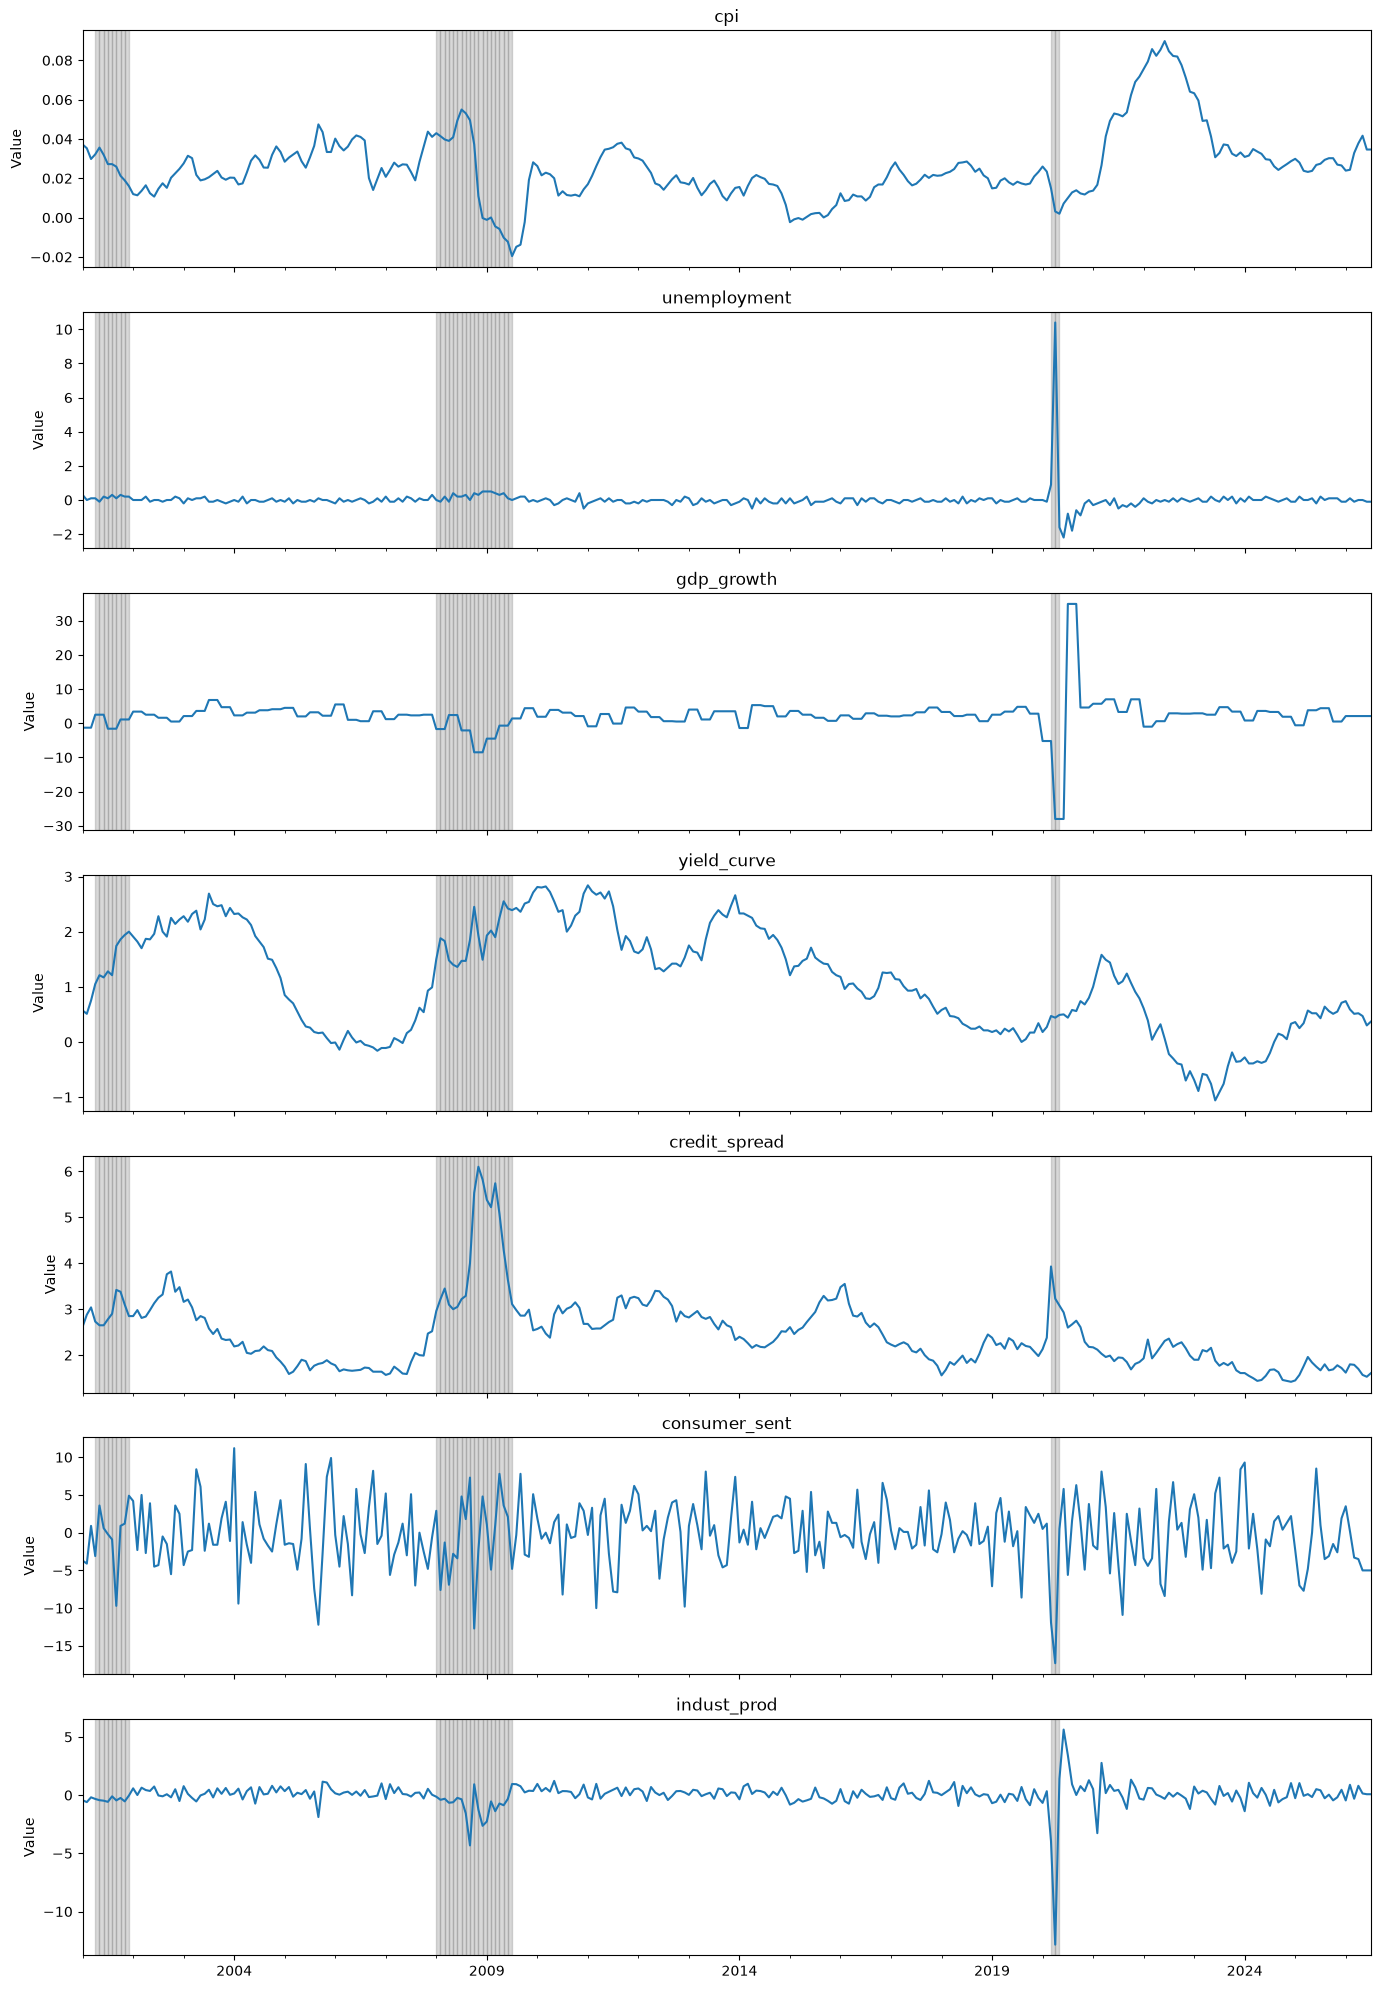

In [55]:
import matplotlib.pyplot as plt
# Now we start plotting with MatPlotLib:
# 1. First plot is a time series of each macro-feature with recession periods shaded in. 

fig, axes = plt.subplots(7, 1, figsize = (14, 20), sharex = True)

for i, col in enumerate(aligned_df.columns):
    ax = axes[i]
    aligned_df[col].plot(ax = ax)
    ax.set_title(col)
    ax.set_ylabel("Value")
    for date, value in recession.items():
        if value == 1:
            ax.axvspan(date, date + pd.offsets.MonthEnd(1), color = 'grey', alpha = 0.3)
        
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'macro_features_eda.png'))
plt.show()

                    cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
cpi            1.000000     -0.062171    0.058771    -0.413775      -0.376575   
unemployment  -0.062171      1.000000   -0.362425    -0.015913       0.129421   
gdp_growth     0.058771     -0.362425    1.000000    -0.031218      -0.281400   
yield_curve   -0.413775     -0.015913   -0.031218     1.000000       0.566471   
credit_spread -0.376575      0.129421   -0.281400     0.566471       1.000000   
consumer_sent -0.097734     -0.256001    0.117988     0.036670      -0.018946   
indust_prod    0.041296     -0.763148    0.295787     0.035505      -0.226530   

               consumer_sent  indust_prod  
cpi                -0.097734     0.041296  
unemployment       -0.256001    -0.763148  
gdp_growth          0.117988     0.295787  
yield_curve         0.036670     0.035505  
credit_spread      -0.018946    -0.226530  
consumer_sent       1.000000     0.159208  
indust_prod         0.159208     1.000000  

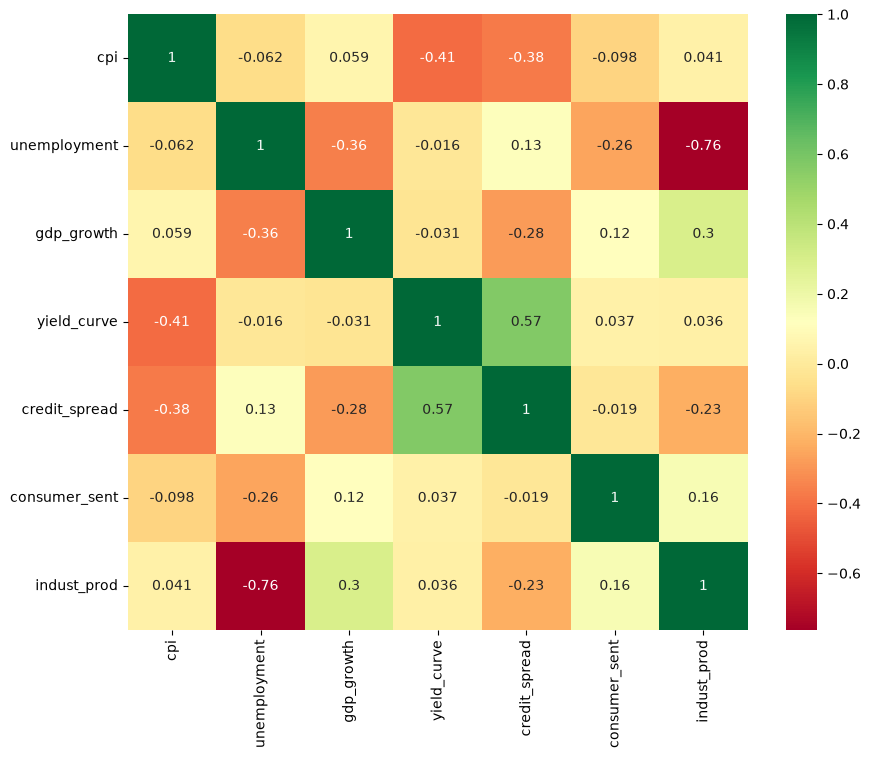

In [56]:
import seaborn as sns

# Using the Seaborn library built on top of matplotlib, created a heatmap showing the correlation between each series. Positive correlation means more alike, negative correlation means less alike. 

corr_matrix = aligned_df.corr()
print(corr_matrix)

hmap = plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'RdYlGn')
plt.savefig(os.path.join(project_root, 'outputs', 'macro_features_heatmap.png'))

    

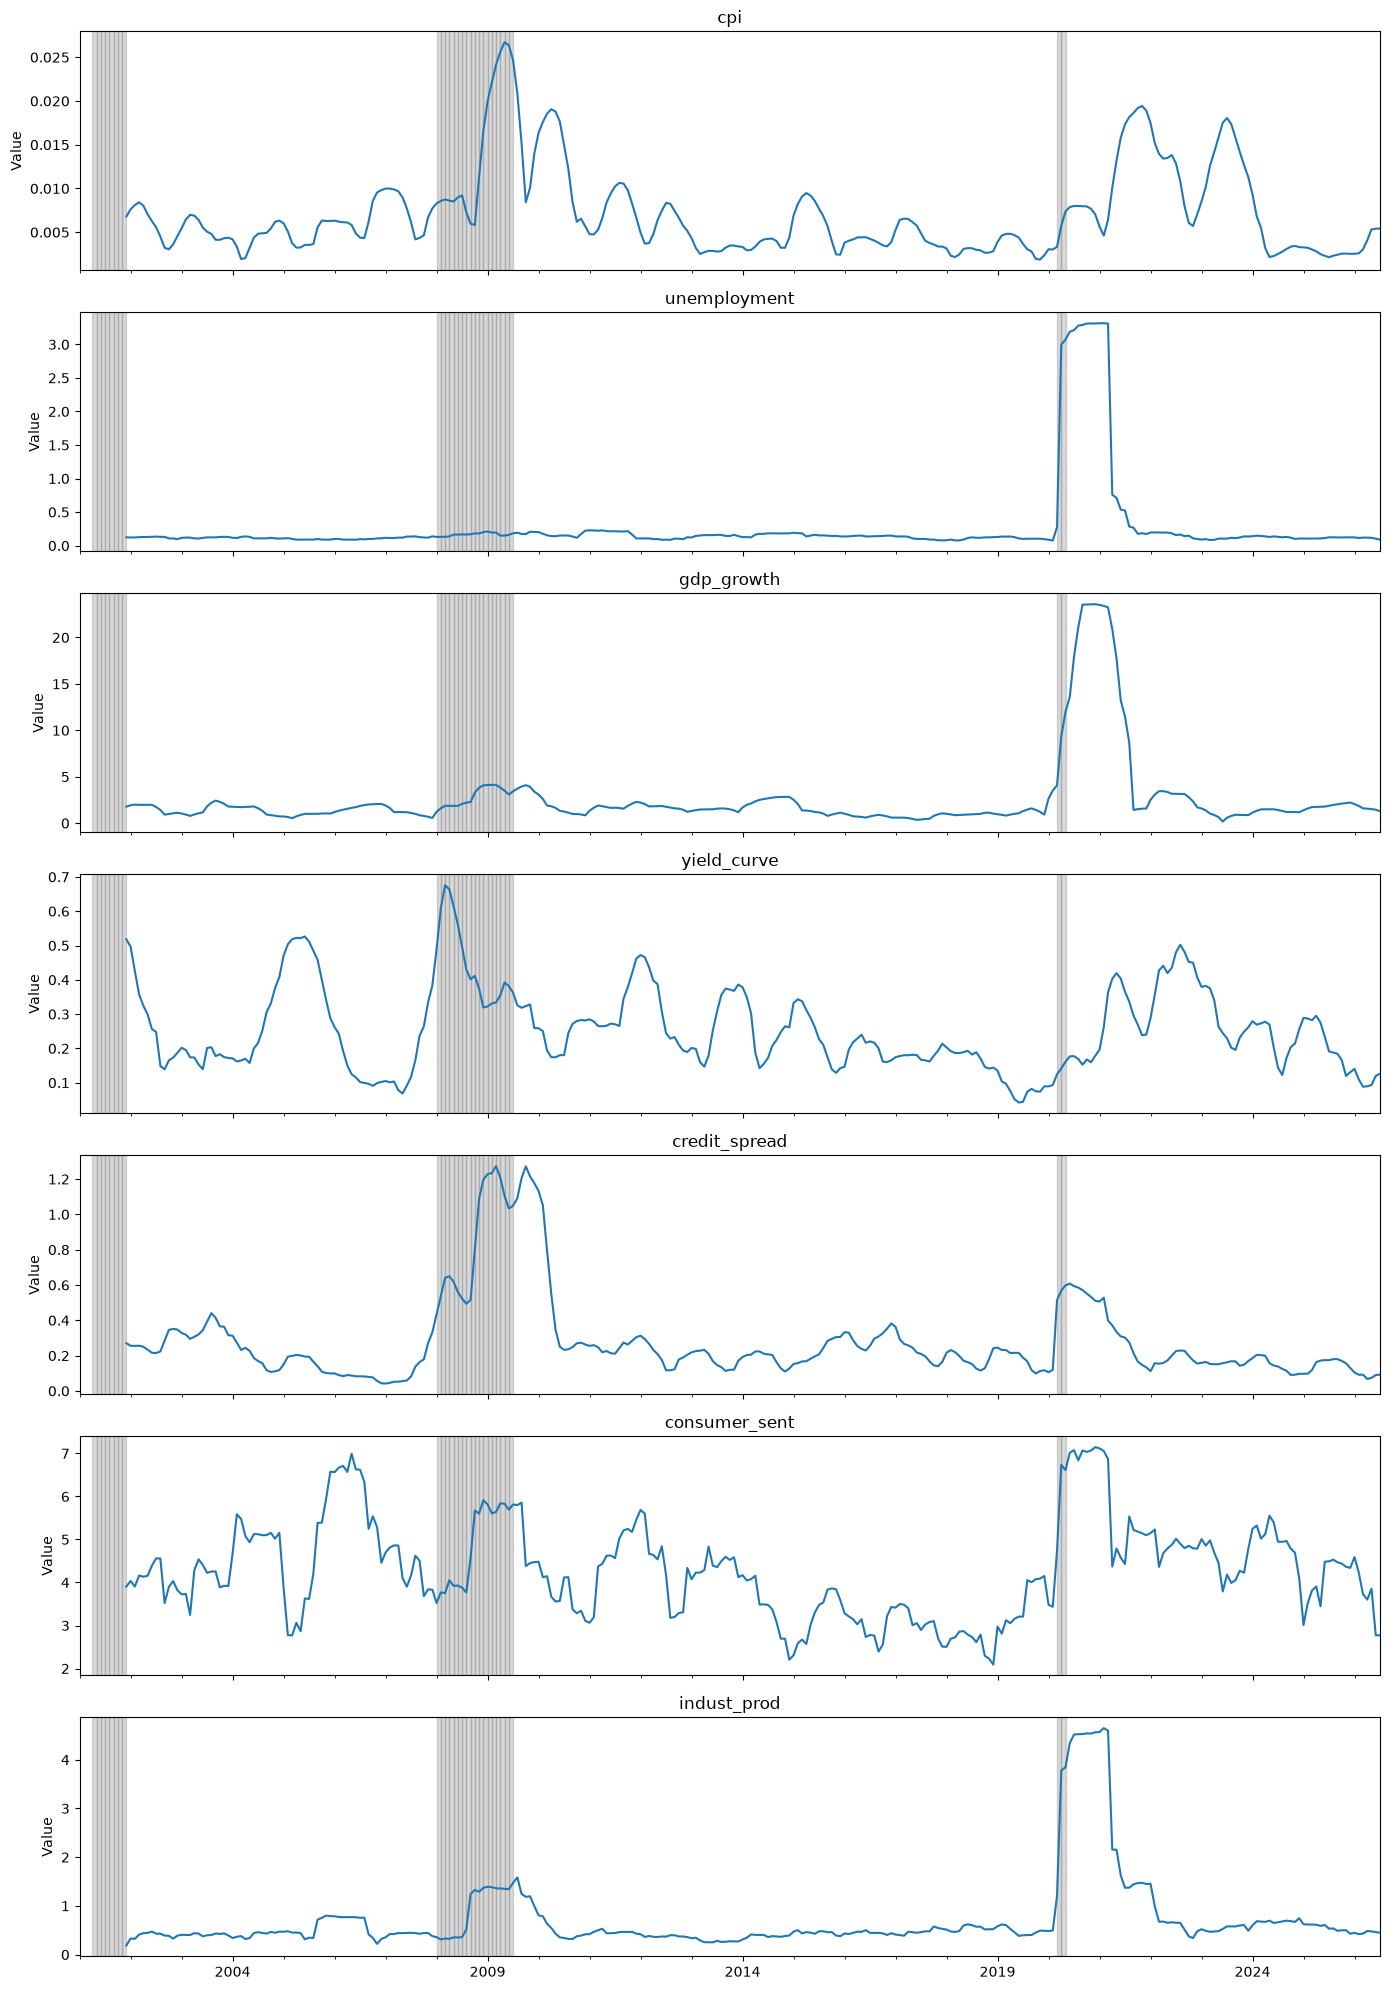

In [57]:
# Compute the rolling 12-month volatility of each macroeconomic indicator and visualize
# how their variability changes over time, with NBER recession periods shaded in gray.

rolling_val = aligned_df.rolling(12).std()

fig, axes = plt.subplots(7, 1, figsize = (14, 20), sharex = True)
for i, col in enumerate(rolling_val.columns):
    ax = axes[i]
    rolling_val[col].plot(ax = ax)
    ax.set_title(col)
    ax.set_ylabel("Value")

    for date, value in recession.items():
        if value == 1:
            ax.axvspan(date, date + pd.offsets.MonthEnd(1), color = 'grey', alpha = 0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'rolling_volatility.png'))
plt.show()